✅ Setup complete


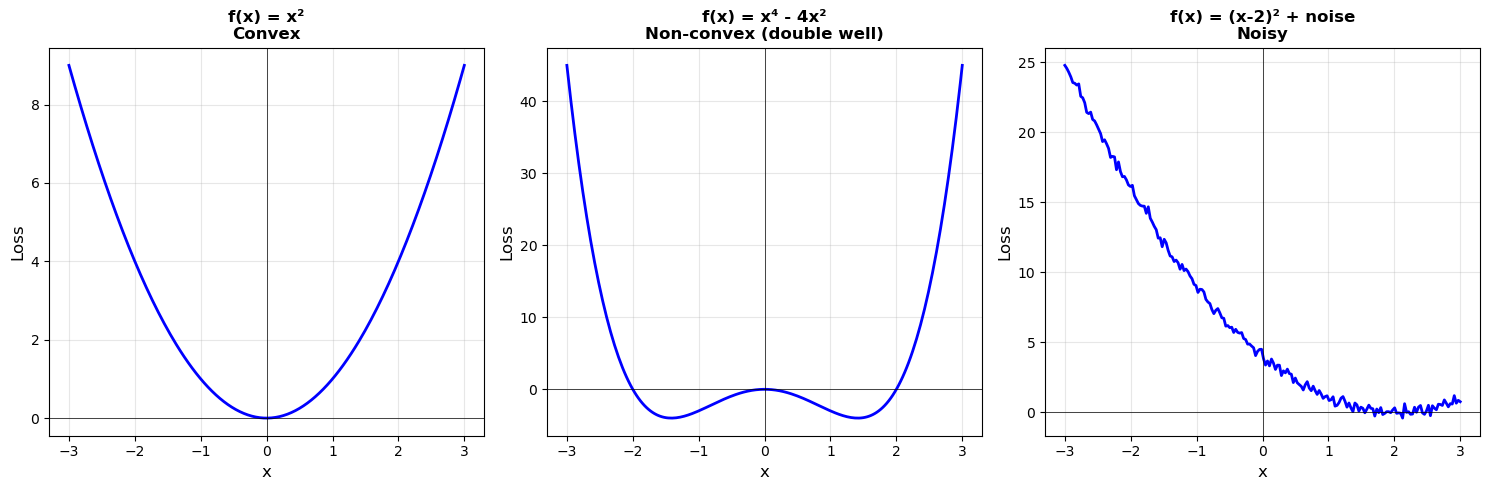

In [1]:
# Cell 1: Define loss functions and their gradients
import numpy as np
import matplotlib.pyplot as plt

print("✅ Setup complete")

# Loss functions and their derivatives
def f1(x):
    """f(x) = x² (convex, simple)"""
    return x**2

def grad_f1(x):
    """df/dx = 2x"""
    return 2*x

def f2(x):
    """f(x) = x⁴ - 4x² (double well, non-convex)"""
    return x**4 - 4*x**2

def grad_f2(x):
    """df/dx = 4x³ - 8x"""
    return 4*x**3 - 8*x

def f3(x):
    """f(x) = (x-2)² + noise (noisy quadratic)"""
    return (x-2)**2 + 0.5 * np.random.normal(0, 0.5, size=len(x)) if isinstance(x, np.ndarray) else (x-2)**2 + 0.5 * np.random.normal(0, 0.5)

def grad_f3(x):
    """df/dx = 2(x-2) (ignoring noise for gradient)"""
    return 2*(x-2)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
functions = [(f1, grad_f1, 'f(x) = x²', 'Convex'), 
             (f2, grad_f2, 'f(x) = x⁴ - 4x²', 'Non-convex (double well)'),
             (f3, grad_f3, 'f(x) = (x-2)² + noise', 'Noisy')]

for idx, (f, grad, title, desc) in enumerate(functions):
    x_vals = np.linspace(-3, 3, 200)
    y_vals = f(x_vals)
    
    axes[idx].plot(x_vals, y_vals, 'b-', linewidth=2)
    axes[idx].set_xlabel('x', fontsize=12)
    axes[idx].set_ylabel('Loss', fontsize=12)
    axes[idx].set_title(f'{title}\n{desc}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axhline(0, color='black', linewidth=0.5)
    axes[idx].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

In [2]:
# Cell 2: Gradient descent implementation
def gradient_descent(f, grad_f, x_start, learning_rate, n_iterations=50):
    """Perform gradient descent and record the path"""
    x_history = [x_start]
    loss_history = [f(x_start)]
    x_current = x_start
    
    for i in range(n_iterations):
        gradient = grad_f(x_current)
        x_current = x_current - learning_rate * gradient
        x_history.append(x_current)
        loss_history.append(f(x_current))
    
    return np.array(x_history), np.array(loss_history)

# Test with different learning rates on f(x)=x²
x_start = 2.5
learning_rates = [0.01, 0.1, 0.8]  # too small, good, too large

print("Testing gradient descent on f(x) = x²")
print("="*50)

for lr in learning_rates:
    x_hist, loss_hist = gradient_descent(f1, grad_f1, x_start, lr, 30)
    print(f"LR={lr}: Final x={x_hist[-1]:.4f}, Final loss={loss_hist[-1]:.6f}, Steps to converge={np.argmin(np.abs(x_hist))}")

Testing gradient descent on f(x) = x²
LR=0.01: Final x=1.3637, Final loss=1.859707, Steps to converge=30
LR=0.1: Final x=0.0031, Final loss=0.000010, Steps to converge=30
LR=0.8: Final x=0.0000, Final loss=0.000000, Steps to converge=30


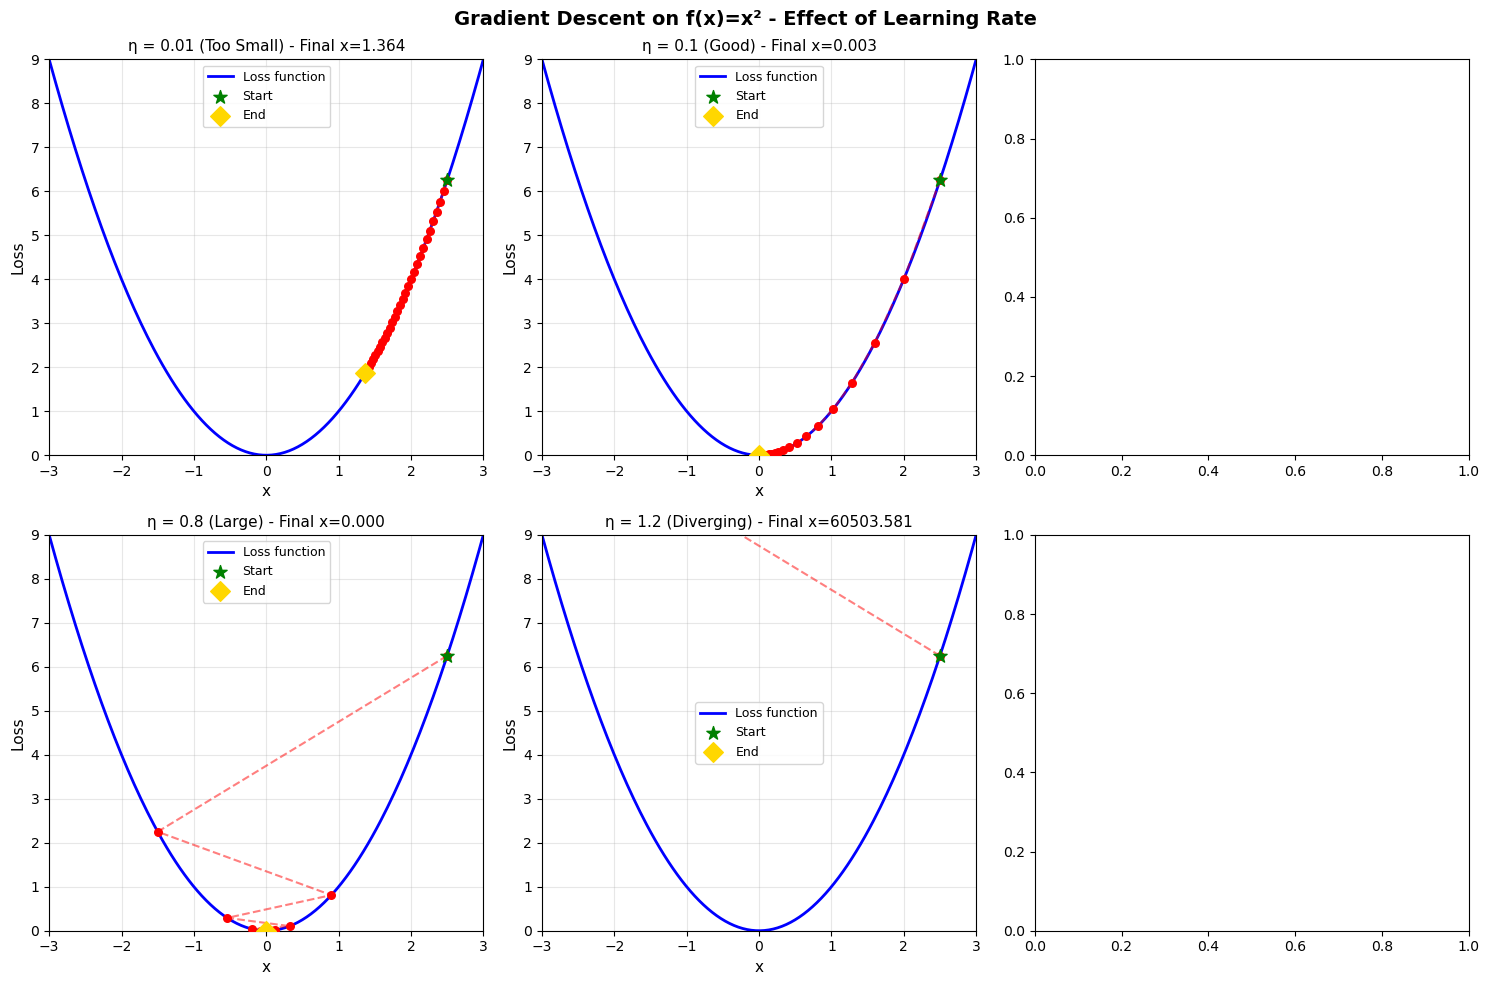

In [3]:
# Cell 3: Visualise descent paths for different learning rates
def plot_gradient_descent_paths():
    """Show how different learning rates affect convergence"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    x_vals = np.linspace(-3, 3, 200)
    x_start = 2.5
    learning_rates = [0.01, 0.1, 0.8, 1.2]
    lr_names = ['η = 0.01 (Too Small)', 'η = 0.1 (Good)', 'η = 0.8 (Large)', 'η = 1.2 (Diverging)']
    
    for idx, (lr, name) in enumerate(zip(learning_rates, lr_names)):
        row = idx // 2
        col = idx % 2
        
        # On f(x)=x²
        x_hist, loss_hist = gradient_descent(f1, grad_f1, x_start, lr, 30)
        
        axes[row, col].plot(x_vals, f1(x_vals), 'b-', linewidth=2, label='Loss function')
        axes[row, col].scatter(x_hist, f1(x_hist), c='red', s=30, zorder=5)
        axes[row, col].plot(x_hist, f1(x_hist), 'r--', alpha=0.5)
        axes[row, col].scatter(x_hist[0], f1(x_hist[0]), c='green', s=100, marker='*', 
                               label='Start', zorder=6)
        axes[row, col].scatter(x_hist[-1], f1(x_hist[-1]), c='gold', s=100, marker='D',
                               label='End', zorder=6)
        
        axes[row, col].set_xlabel('x', fontsize=11)
        axes[row, col].set_ylabel('Loss', fontsize=11)
        axes[row, col].set_title(f'{name} - Final x={x_hist[-1]:.3f}', fontsize=11)
        axes[row, col].legend(fontsize=9)
        axes[row, col].grid(True, alpha=0.3)
        axes[row, col].set_xlim(-3, 3)
        axes[row, col].set_ylim(0, 9)
    
    plt.suptitle('Gradient Descent on f(x)=x² - Effect of Learning Rate', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_gradient_descent_paths()

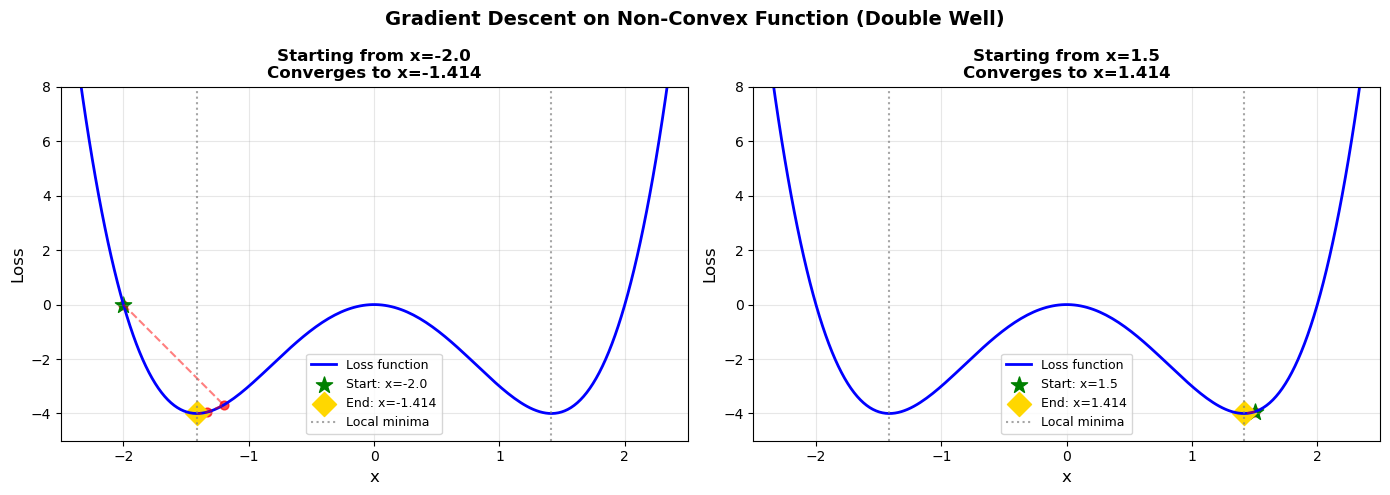


💡 Insight: Starting point matters for non-convex functions!
   Different starting positions can converge to different minima.


In [4]:
# Cell 4: Gradient descent on non-convex function
def explore_non_convex():
    """Show gradient descent on f(x)=x⁴-4x² (has two minima)"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x_vals = np.linspace(-2.5, 2.5, 200)
    x_start_options = [-2.0, 1.5]
    learning_rate = 0.05
    
    for idx, x_start in enumerate(x_start_options):
        x_hist, loss_hist = gradient_descent(f2, grad_f2, x_start, learning_rate, 40)
        
        axes[idx].plot(x_vals, f2(x_vals), 'b-', linewidth=2, label='Loss function')
        axes[idx].scatter(x_hist, f2(x_hist), c='red', s=40, alpha=0.7)
        axes[idx].plot(x_hist, f2(x_hist), 'r--', alpha=0.5)
        axes[idx].scatter(x_hist[0], f2(x_hist[0]), c='green', s=150, marker='*', 
                          label=f'Start: x={x_start}')
        axes[idx].scatter(x_hist[-1], f2(x_hist[-1]), c='gold', s=150, marker='D',
                          label=f'End: x={x_hist[-1]:.3f}')
        
        # Mark minima locations
        axes[idx].axvline(-np.sqrt(2), color='gray', linestyle=':', alpha=0.7, label='Local minima')
        axes[idx].axvline(np.sqrt(2), color='gray', linestyle=':', alpha=0.7)
        
        axes[idx].set_xlabel('x', fontsize=12)
        axes[idx].set_ylabel('Loss', fontsize=12)
        axes[idx].set_title(f'Starting from x={x_start}\nConverges to x={x_hist[-1]:.3f}', 
                           fontsize=12, fontweight='bold')
        axes[idx].legend(fontsize=9)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_xlim(-2.5, 2.5)
        axes[idx].set_ylim(-5, 8)
    
    plt.suptitle('Gradient Descent on Non-Convex Function (Double Well)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Insight: Starting point matters for non-convex functions!")
    print("   Different starting positions can converge to different minima.")

explore_non_convex()

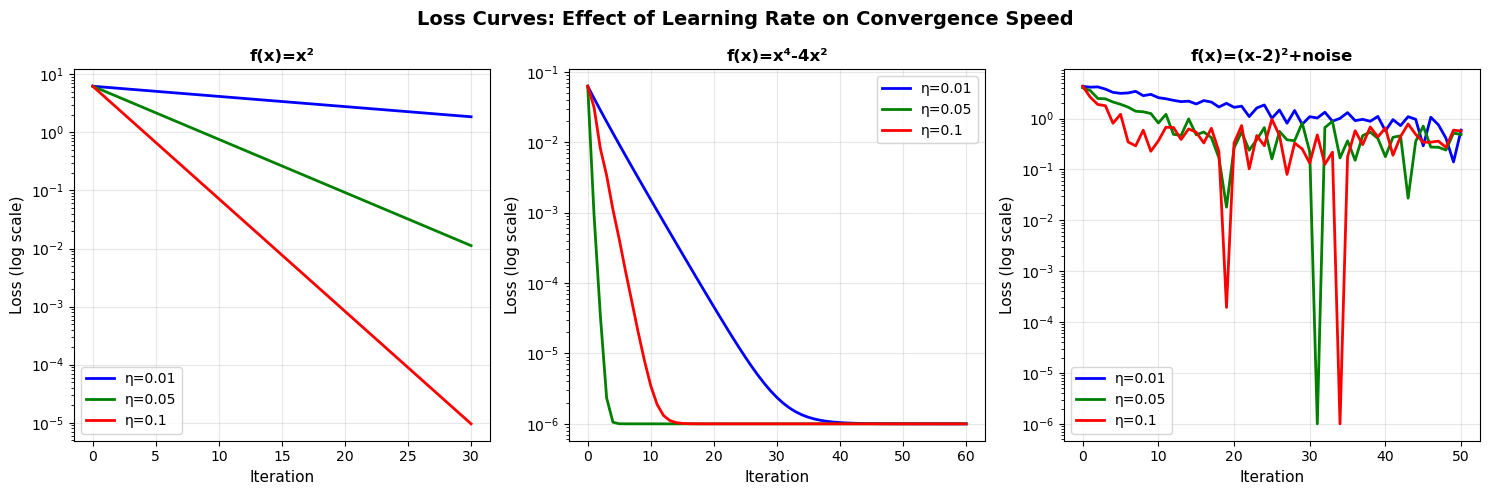

In [8]:
def plot_loss_curves():
    """Plot loss vs iteration for different learning rates"""
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    functions = [
        (f1, grad_f1, 'f(x)=x²', 30), 
        (f2, grad_f2, 'f(x)=x⁴-4x²', 60),
        (f3, grad_f3, 'f(x)=(x-2)²+noise', 50)
    ]
    
    # Smaller learning rates
    learning_rates = [0.01, 0.05, 0.1]
    
    colors = ['blue', 'green', 'red']
    
    for idx, (f, grad, title, n_iter) in enumerate(functions):
        
        for lr, color in zip(learning_rates, colors):
            
            # Different starting points
            if idx == 0:
                x_start = 2.5
            elif idx == 1:
                x_start = 1.5
            else:
                x_start = 4
            
            try:
                # Run gradient descent
                _, loss_hist = gradient_descent(
                    f, grad, x_start, lr, n_iter
                )
                
                # Ensure positive values for log scale
                if np.any(loss_hist <= 0):
                    loss_hist = loss_hist - np.min(loss_hist) + 1e-6
                
                # Plot
                axes[idx].plot(
                    range(len(loss_hist)),
                    loss_hist,
                    color=color,
                    linewidth=2,
                    label=f'η={lr}'
                )
            
            except OverflowError:
                print(f"Overflow occurred for {title} with learning rate {lr}")
        
        axes[idx].set_xlabel('Iteration', fontsize=11)
        axes[idx].set_ylabel('Loss (log scale)', fontsize=11)
        axes[idx].set_title(title, fontsize=12, fontweight='bold')
        
        axes[idx].set_yscale('log')
        
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.suptitle(
        'Loss Curves: Effect of Learning Rate on Convergence Speed',
        fontsize=14,
        fontweight='bold'
    )
    
    plt.tight_layout()
    plt.show()


# Run function
plot_loss_curves()